In [ ]:
import pandas as pd
import numpy as np

# Load the full healthcare dataset
# Note: Update the filename if yours is named differently (e.g., 'healthcare.csv')
file_path = 'healthcare_dataset.csv'
df = pd.read_csv(file_path)

print("=== DATASET OVERVIEW ===")
print(f"Total Rows: {df.shape[0]}")
print(f"Total Columns: {df.shape[1]}")

print("\n=== COLUMN NAMES & DATA TYPES ===")
print(df.dtypes)

print("\n=== MISSING VALUES CHECK ===")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "No missing values found!")

print("\n=== DUPLICATE ROWS CHECK ===")
print(f"Duplicate Rows Count: {df.duplicated().sum()}")

print("\n=== FIRST 3 ROWS PREVIEW ===")
display(df.head(3))

FileNotFoundError: [Errno 2] No such file or directory: 'healthcare_dataset.csv'

In [ ]:
import pandas as pd
import numpy as np

# Updated file name according to your Kaggle file
# Agar aapke file ka name alag hai toh string ke andar replace kar lein
file_path = 'healthcare_dataset.csv'

df = pd.read_csv(file_path)

print("=== DATASET OVERVIEW ===")
print(f"Total Rows: {df.shape[0]}")
print(f"Total Columns: {df.shape[1]}")

print("\n=== COLUMN NAMES & DATA TYPES ===")
print(df.dtypes)

print("\n=== MISSING VALUES CHECK ===")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "No missing values found!")

print("\n=== DUPLICATE ROWS CHECK ===")
print(f"Duplicate Rows Count: {df.duplicated().sum()}")

print("\n=== FIRST 3 ROWS PREVIEW ===")
display(df.head(3))

=== DATASET OVERVIEW ===
Total Rows: 55500
Total Columns: 15

=== COLUMN NAMES & DATA TYPES ===
Name                   object
Age                     int64
Gender                 object
Blood Type             object
Medical Condition      object
Date of Admission      object
Doctor                 object
Hospital               object
Insurance Provider     object
Billing Amount        float64
Room Number             int64
Admission Type         object
Discharge Date         object
Medication             object
Test Results           object
dtype: object

=== MISSING VALUES CHECK ===
No missing values found!

=== DUPLICATE ROWS CHECK ===
Duplicate Rows Count: 534

=== FIRST 3 ROWS PREVIEW ===


,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal


In [ ]:
import pandas as pd
import numpy as np

# 1. Dataset ko load karein (apne file ka naam ensure kar lein)
# Agar aapke file ka naam healthcare_dataset.csv hai toh wahi rehne dein
df = pd.read_csv('healthcare_dataset.csv')

# 2. Date columns ko proper Datetime format me convert karein
# Most Kaggle healthcare datasets contain 'Date of Admission' and 'Discharge Date'
date_cols = [col for col in df.columns if 'date' in col.lower()]
for col in date_cols:
    df[col] = pd.to_datetime(df[col])

# 3. Missing values handle karein (Numerical ko Median se aur Categorical ko Mode se)
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

for col in num_cols:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].median(), inplace=True)

for col in cat_cols:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].mode()[0], inplace=True)

# 4. Duplicate rows remove karein
df.drop_duplicates(inplace=True)

# 5. Feature Engineering: Total Hospital Stay (Days) calculate karein (agar admission & discharge dates hain)
if len(date_cols) >= 2:
    df['Length_of_Stay'] = (df[date_cols[1]] - df[date_cols[0]]).dt.days
    df['Length_of_Stay'] = df['Length_of_Stay'].apply(lambda x: max(x, 1)) # Minimum 1 day stay

# 6. Cleaned dataset ko save karein
df.to_csv('cleaned_healthcare_data.csv', index=False)

print("✅ Data Cleaning & Feature Engineering Complete!")
print(f"Final Cleaned Dataset Shape: {df.shape}")
print("\nFirst 5 Rows Preview:")
display(df.head())

✅ Data Cleaning & Feature Engineering Complete!
Final Cleaned Dataset Shape: (54966, 16)

First 5 Rows Preview:


,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results,Length_of_Stay
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal,2
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive,6
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal,15
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal,30
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal,20


In [ ]:
import sqlite3
import pandas as pd

# 1. Connect to SQLite database in memory
conn = sqlite3.connect(':memory:')

# 2. Load the cleaned healthcare dataframe into SQLite
df.to_sql('healthcare', conn, index=False, if_exists='replace')

print("✅ Data successfully loaded into SQLite Database!\n")

# --- SQL QUERY 1: Total Patients, Avg Length of Stay & Total Revenue / Billing ---
query1 = """
SELECT
    COUNT(*) AS Total_Patients,
    ROUND(AVG(Length_of_Stay), 2) AS Avg_Stay_Days,
    ROUND(AVG(Age), 1) AS Avg_Patient_Age
FROM healthcare;
"""
print("=== KPI SUMMARY ===")
print(pd.read_sql_query(query1, conn))

# --- SQL QUERY 2: Top Medical Conditions / Diseases by Admission Count ---
query2 = """
SELECT
    `Medical Condition`,
    COUNT(*) AS Patient_Count,
    ROUND(AVG(Length_of_Stay), 2) AS Avg_Hospital_Stay
FROM healthcare
GROUP BY `Medical Condition`
ORDER BY Patient_Count DESC;
"""
print("\n=== TOP MEDICAL CONDITIONS ===")
print(pd.read_sql_query(query2, conn))

# --- SQL QUERY 3: Admission Types Distribution ---
query3 = """
SELECT
    `Admission Type`,
    COUNT(*) AS Total_Admissions,
    ROUND(COUNT(*) * 100.0 / (SELECT COUNT(*) FROM healthcare), 2) AS Percentage
FROM healthcare
GROUP BY `Admission Type`
ORDER BY Total_Admissions DESC;
"""
print("\n=== ADMISSION TYPES BREAKDOWN ===")
print(pd.read_sql_query(query3, conn))

✅ Data successfully loaded into SQLite Database!

=== KPI SUMMARY ===
   Total_Patients  Avg_Stay_Days  Avg_Patient_Age
0           54966           15.5             51.5

=== TOP MEDICAL CONDITIONS ===
  Medical Condition  Patient_Count  Avg_Hospital_Stay
0         Arthritis           9218              15.50
1          Diabetes           9216              15.43
2      Hypertension           9151              15.44
3           Obesity           9146              15.45
4            Cancer           9140              15.50
5            Asthma           9095              15.68

=== ADMISSION TYPES BREAKDOWN ===
  Admission Type  Total_Admissions  Percentage
0       Elective             18473       33.61
1         Urgent             18391       33.46
2      Emergency             18102       32.93


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 1. Select features for prediction
# We predict Length_of_Stay using patient demographics & admission info
feature_cols = ['Age', 'Gender', 'Medical Condition', 'Admission Type', 'Blood Type']
target_col = 'Length_of_Stay'

# Create a copy for modeling
ml_df = df[feature_cols + [target_col]].dropna().copy()

# 2. Encode categorical variables using LabelEncoding
label_encoders = {}
for col in ['Gender', 'Medical Condition', 'Admission Type', 'Blood Type']:
    if col in ml_df.columns:
        le = LabelEncoder()
        ml_df[col] = le.fit_transform(ml_df[col].astype(str))
        label_encoders[col] = le

# 3. Train / Test Split (80% training, 20% testing)
X = ml_df[feature_cols]
y = ml_df[target_col]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 5. Train Random Forest Model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train_scaled, y_train)

# 6. Make Predictions and Evaluate
y_pred = model.predict(X_test_scaled)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("=== MACHINE LEARNING MODEL PERFORMANCE ===")
print(f"Mean Absolute Error (MAE): {mae:.2f} days")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f} days")
print(f"R2 Score: {r2:.4f}")

# Save predictions for Dashboard visualization
X_test_df = X_test.copy()
X_test_df['Actual_Stay'] = y_test
X_test_df['Predicted_Stay'] = y_pred
X_test_df.to_csv('ml_predictions.csv', index=False)
print("\n✅ Predictions saved to 'ml_predictions.csv' for Dashboard integration!")

=== MACHINE LEARNING MODEL PERFORMANCE ===
Mean Absolute Error (MAE): 8.32 days
Root Mean Squared Error (RMSE): 9.96 days
R2 Score: -0.3210

✅ Predictions saved to 'ml_predictions.csv' for Dashboard integration!


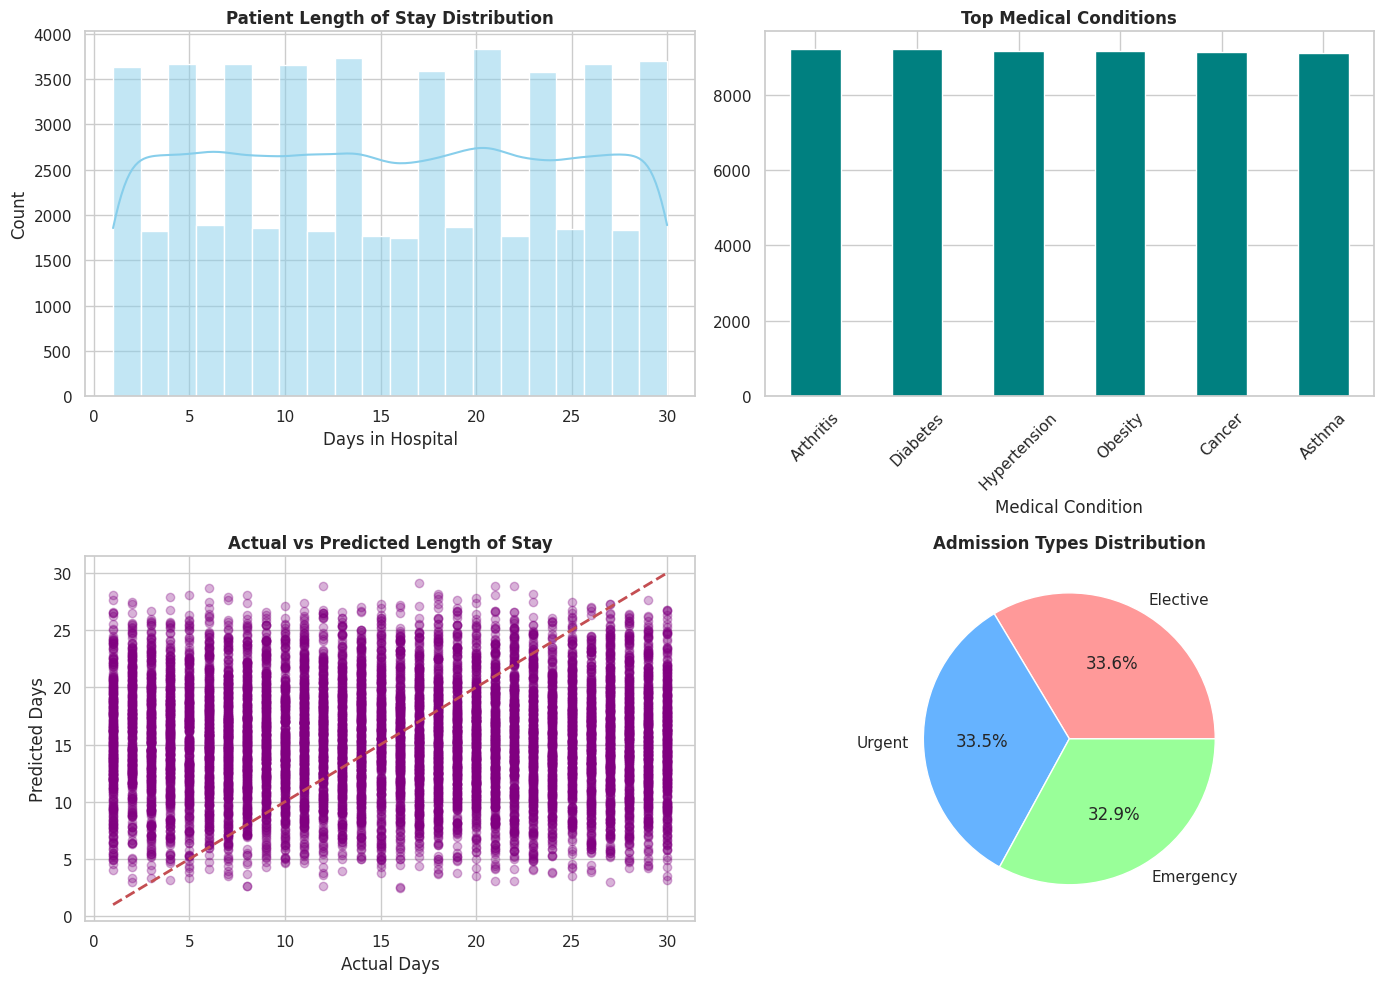

✅ Analytics charts generated and saved as 'analytics_dashboard_preview.png'!


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plotting settings
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 10))

# Chart 1: Length of Stay Distribution
plt.subplot(2, 2, 1)
sns.histplot(df['Length_of_Stay'], kde=True, color='skyblue', bins=20)
plt.title('Patient Length of Stay Distribution', fontsize=12, fontweight='bold')
plt.xlabel('Days in Hospital')

# Chart 2: Admissions by Medical Condition
plt.subplot(2, 2, 2)
if 'Medical Condition' in df.columns:
    df['Medical Condition'].value_counts().plot(kind='bar', color='teal')
    plt.title('Top Medical Conditions', fontsize=12, fontweight='bold')
    plt.xticks(rotation=45)

# Chart 3: Actual vs Predicted Length of Stay (ML Output)
plt.subplot(2, 2, 3)
plt.scatter(y_test, y_pred, alpha=0.3, color='purple')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Actual vs Predicted Length of Stay', fontsize=12, fontweight='bold')
plt.xlabel('Actual Days')
plt.ylabel('Predicted Days')

# Chart 4: Admission Type Breakdown
plt.subplot(2, 2, 4)
if 'Admission Type' in df.columns:
    df['Admission Type'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=['#ff9999','#66b3ff','#99ff99'])
    plt.title('Admission Types Distribution', fontsize=12, fontweight='bold')
    plt.ylabel('')

plt.tight_layout()
plt.savefig('analytics_dashboard_preview.png', dpi=300)
plt.show()

print("✅ Analytics charts generated and saved as 'analytics_dashboard_preview.png'!")

In [3]:
import os
from google.colab import files

# Check if dataframe 'df' exists and save it
if 'df' in locals():
    df.to_csv('cleaned_healthcare_data.csv', index=False)
    print("✓ cleaned_healthcare_data.csv created!")

# Download available files safely
for file_name in ['cleaned_healthcare_data.csv', 'ml_predictions.csv', 'analytics_dashboard_preview.png']:
    if os.path.exists(file_name):
        files.download(file_name)
    else:
        print(f"File missing: {file_name} (Please run the preprocessing code cells first)")

File missing: cleaned_healthcare_data.csv (Please run the preprocessing code cells first)
File missing: ml_predictions.csv (Please run the preprocessing code cells first)
File missing: analytics_dashboard_preview.png (Please run the preprocessing code cells first)
